In [1]:
# Set autoreload
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import warnings
import pandas as pd
import numpy as np
import sys; sys.path.insert(0, '..')

from src.data_prep import prepare_default_accounts, build_monthly_panel
from src.plot_function import plot_res_type, plot_recov_type

pd.options.display.float_format = '{:.3f}'.format
np.set_printoptions(suppress = True)
warnings.simplefilter(action ='ignore', category = pd.errors.PerformanceWarning)
warnings.filterwarnings('ignore', category = RuntimeWarning)
warnings.filterwarnings('ignore', category = UserWarning)

In [3]:
# Import transaction data
df = pd.read_parquet(
    '../data/raw/main_transaction_data.parquet',
    engine = 'pyarrow'
)

In [4]:
# Import cashflow data
cashflow = pd.read_parquet(
    '../data/raw/cashflow_data.parquet',
    engine = 'pyarrow'
)

## Data structure
### Active transaction
The dataset of active transaction is contained all active customer in the portfolio. It included performing customer who currently repay the loan and non-performing customer who default but still active by repay the loan later. For non-performing customer and loss, those will be transformed into collection process.

### Cashflow transaction
The dataset of cashflow transaction is contained all cashflow in the portfolio. It included repayment cashflow for performing customer and recovery from collection process for non-performing customer.

### The process structure
There are 5 default cases identified in this dataset:

> **Process Structure**
>
> Default  
> ├── Open (Censored)  
> ├──  Resolved  
> ├── ├── Normal          (Normal closed: Status = 0)<br>
> ├── ├── Repossession    (Auction closed: Status = 202)<br>
> ├── ├── Loss            (Total loss: Status = 204)<br>
> └── └── Damage          (Car damage: Status = 205)<br>

<div style="border:1px solid #ddd; padding:12px; border-radius:6px;box-sizing:border-box; font-family:monospace;">
  <b>Example censored (100) case</b><br><br>

  <div style="display:flex;">
    <div style="width:200px;">Performing</div>
    <div style="width:200px;">Default</div>
    <div style="width:200px;">Last period</div>
  </div>

  <div style="display:flex;">
    <div style="width:200px;">t------------------^</div>
    <div style="width:200px;">-------------------o</div>
  </div>

  <div style="display:flex; margin-top:6px;">
    <div style="width:200px;"></div>
    <div style="width:200px;">Repayment</div>
    <div style="width:200px;">Censor<br>(No collection)</div>
  </div>
</div>

<br>

<div style="border:1px solid #ddd; padding:12px; border-radius:6px;box-sizing:border-box; font-family:monospace;">
  <b>Example normal (0) case</b><br><br>

  <div style="display:flex;">
    <div style="width:200px;">Performing</div>
    <div style="width:200px;">Default</div>
    <div style="width:200px;">Closed</div>
  </div>

  <div style="display:flex;">
    <div style="width:200px;">t------------------^</div>
    <div style="width:200px;">-------------------o</div>
  </div>

  <div style="display:flex; margin-top:6px;">
    <div style="width:200px;"></div>
    <div style="width:200px;">Repayment</div>
    <div style="width:200px;">Resolved<br>(No collection)</div>
  </div>
</div>

<br>

<div style="border:1px solid #ddd; padding:12px; border-radius:6px;box-sizing:border-box; font-family:monospace;">
  <b>Example non-normal (202, 204, 205) cases</b><br><br>

  <div style="display:flex;">
    <div style="width:200px;">Performing</div>
    <div style="width:200px;">Default</div>
    <div style="width:200px;">Collection</div>
    <div style="width:200px;">Resolved</div>
  </div>

  <div style="display:flex;">
    <div style="width:200px;">t------------------^</div>
    <div style="width:200px;">-------------------></div>
    <div style="width:200px;">-------------------o</div>
  </div>

  <div style="display:flex; margin-top:6px;">
    <div style="width:200px;"></div>
    <div style="width:200px;">Repayment</div>
    <div style="width:200px;">Recovery</div>
  </div>
</div>

In [5]:
# Constant parameters
# Default information
ACC_ID_COL = "acc_id" #Primary key
DEFAULT_COL = "aging" #Default column
DEFAULT_FLAG = 4 #Any values greater than this value will be considered as default
DATE_COL = "as_of_date" #Date column
STATUS_COL = "acc_status" #Status column
RESOLUTION_DATE = "resolution_date" #Closed or terminate date column
LAST_PERIOD = df['as_of_date'].max() #Last snapshot as censoring cases (open)

# Cash information
DEFAULT_DATE = "default_date" #First default date
RESOLUTION_COL = "resolved" #Resolution flag --> (0, 1)
RESOLUTION_TYPE = "resolution_type" #Resolution types --> (0: Normal, 202: Repossession, 204: Loss, 205: Damage, 100: Censor)

In [6]:
# Prepared default information
df_account = prepare_default_accounts(
    df_raw = df,
    df_cashflows = cashflow,
    acc_id_col = ACC_ID_COL,
    default_col = DEFAULT_COL,
    default_flag = DEFAULT_FLAG,
    date_col = DATE_COL,
    resolution_col = STATUS_COL,
    resolution_date = RESOLUTION_DATE,
    last_period = LAST_PERIOD
)

# Keep only for model information
keep_cols = [
    "default_date",
    "acc_id",
    "acc_status",
    "ead",
    "eir",
    "resolution_date",
    "resolution_type",
    "resolved",
    "time_to_resolution"
]
df_account = df_account[keep_cols].reset_index(drop = True)

# Show table
df_account.head(5)

=== Processing ===
[INFO]: Identify default population
[INFO]: Identify resolution types
[INFO]: Compute time to resolution
[INFO]: Number of defualt: 24808


,default_date,acc_id,acc_status,ead,eir,resolution_date,resolution_type,resolved,time_to_resolution
0,2014-07-31,511017766,100,14364.000,0.071,2014-08-31,0,1,1
1,2014-03-31,511018708,100,62702.020,0.077,2014-06-30,0,1,3
2,2014-09-30,511019278,100,12782.590,0.065,2014-10-31,0,1,1
3,2014-06-30,511021648,100,50748.210,0.076,2014-08-31,0,1,2
4,2014-02-28,511024282,100,90247.650,0.051,2019-11-30,204,1,69


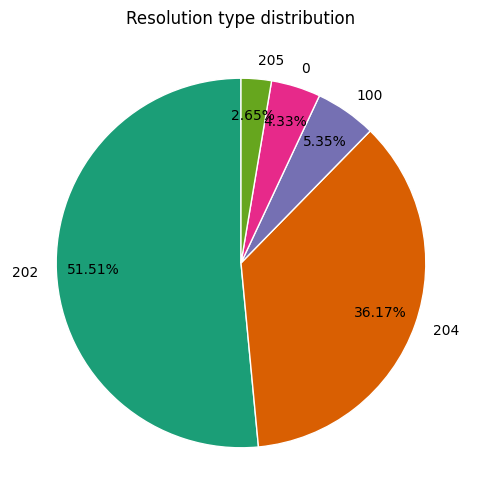

In [7]:
# Plot resolution type
plot_res_type(df_account)

In [8]:
# Building monthly panel
df_recovery = build_monthly_panel(
    df_accounts = df_account,
    df_cashflows = cashflow,
    acc_id_col = ACC_ID_COL,
    date_col = DATE_COL,
    default_date = DEFAULT_DATE,
    resolution_col = RESOLUTION_COL,
    resolution_date = RESOLUTION_DATE,
    resolution_type = RESOLUTION_TYPE,
    last_period = LAST_PERIOD
)

# Show table
df_recovery.head(5)

=== Processing ===
[INFO]: Panel monthly cashflow for default population


,as_of_date,acc_id,month_since_default,amount,resolution_type,is_resolution_month,resolved
0,2014-07-31,511017766,0,0.000,0,0,1
1,2014-08-31,511017766,1,14364.000,0,1,1
2,2014-03-31,511018708,0,0.000,0,0,1
3,2014-04-30,511018708,1,39471.560,0,0,1
4,2014-05-31,511018708,2,0.000,0,0,1


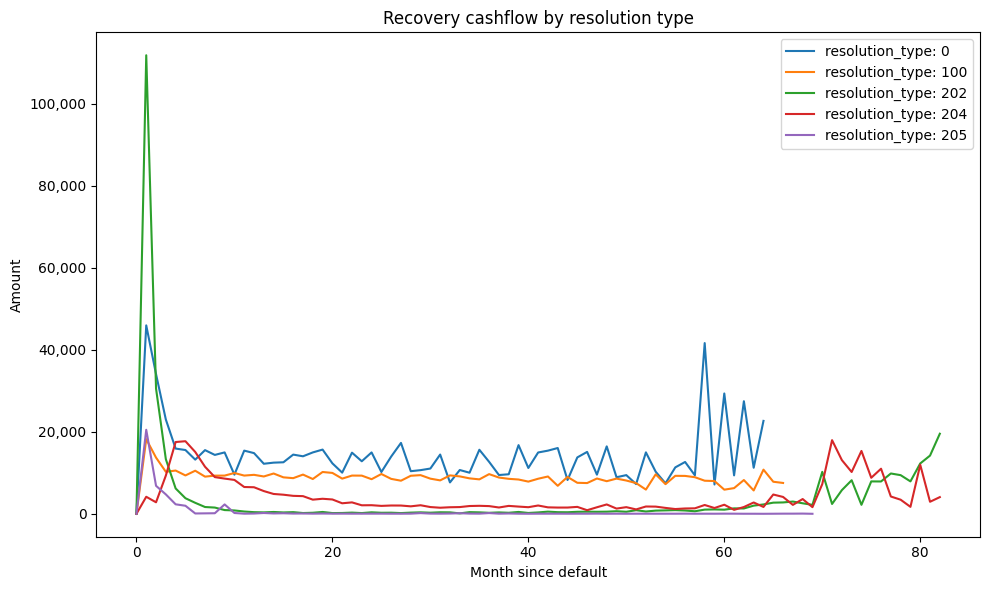

In [9]:
# Plot recovery by resolution type
plot_recov_type(df_recovery)

In [10]:
# Export
df_account.to_parquet(
    '../data/processed/default_account.parquet',
    engine = 'pyarrow'
)
df_recovery.to_parquet(
    '../data/processed/default_cashflow.parquet',
    engine = 'pyarrow'
)